In [34]:
suppressPackageStartupMessages({
    library(tidyverse)
    library(arrow)
    })

In [28]:
version <- 'EDP1-EDP2-ARB'
src_dir <- paste0('out_rds/', version)
dst_dir <- paste0('/data/srlab/AMP_collab/data/early_disease_synovium/xenium/combined/', version)

In [36]:
meta <- read_parquet(paste0(dst_dir, '/allcells_qc_harmumapclust_lineage[metadata-tiles].parquet'))
meta <- as.data.frame(meta)
rownames(meta) <- meta$cell_id

In [37]:
meta$coarsetype = NA

files <- Sys.glob(paste0(src_dir, "/*/*/*_allcells_coarsetypesvector.rds"))
message("Found ", length(files), " files")

for (i in seq_along(files)) {
    file <- files[[i]]
    message(sprintf("  [%d/%d] Reading: %s", i, length(files), basename(file)))
    
    vec <- readRDS(file)
    cells_in_common <- intersect(names(vec), rownames(meta))
    meta[cells_in_common, "coarsetype"] <- vec[cells_in_common]
}

message("Done. Non-NA coarsetypes: ", sum(!is.na(meta$coarsetype)), " / ", nrow(meta))

Found 11 files

  [1/11] Reading: B_allcells_coarsetypesvector.rds

  [2/11] Reading: Plasma_allcells_coarsetypesvector.rds

  [3/11] Reading: Lymphatic endothelial_allcells_coarsetypesvector.rds

  [4/11] Reading: Vascular endothelial_allcells_coarsetypesvector.rds

  [5/11] Reading: Dendritic cell_allcells_coarsetypesvector.rds

  [6/11] Reading: Macrophage_allcells_coarsetypesvector.rds

  [7/11] Reading: Lining_allcells_coarsetypesvector.rds

  [8/11] Reading: Mural_allcells_coarsetypesvector.rds

  [9/11] Reading: Sublining_allcells_coarsetypesvector.rds

  [10/11] Reading: NK_allcells_coarsetypesvector.rds

  [11/11] Reading: T_allcells_coarsetypesvector.rds

Done. Non-NA coarsetypes: 4162785 / 5150888



In [42]:
# carry forward lineages for those lineages that were not subtyped
for (ct in c("Mural", "Neuronal/glial", "Myeloid+B/plasma", "Myeloid+Stromal", "Osteoclast", "Proliferating", "Mast", "Adipocyte", "Low quality"))
{
    meta$coarsetype[meta$lineage == ct] <- ct
}

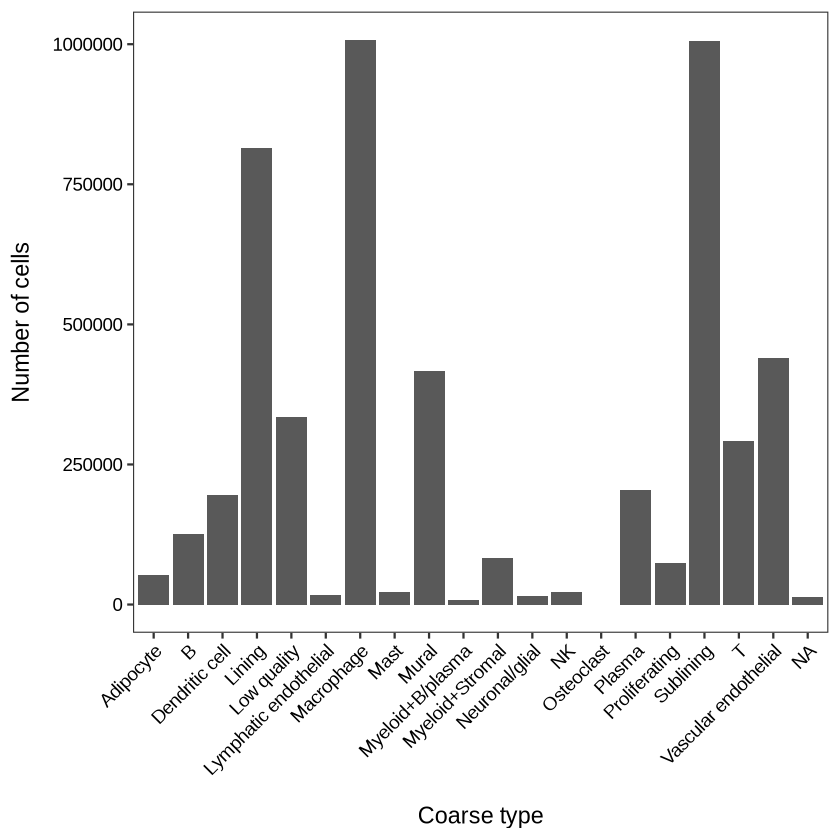

In [43]:
ggplot(meta, aes(x = coarsetype)) +
    geom_bar() +
    theme_bw(base_size = 14) +
    theme(axis.text.x = element_text(angle = 45, hjust = 1, color = "black"),
          axis.text.y = element_text(color = "black"),
          panel.grid  = element_blank()) +
    xlab("Coarse type") + ylab("Number of cells")

In [44]:
# save
write_parquet(meta, paste0(dst_dir, '/allcells_qc_harmumapclust_lineage[metadata-tiles_coarsetypes]_replacetheotherone.parquet'))

In [50]:
files <- Sys.glob(paste0(src_dir, "/*/*/*_allcells_coarsetypes_umap.rds"))
message("Found ", length(files), " files")

for (i in seq_along(files)) {
    file <- files[[i]]
    ct <- stringr::str_split_i(basename(file), "_", 1)
    message(sprintf("  [%d/%d] Copying %s to %s", 
                    i, length(files), basename(file), file.path(dst_dir, 'coarsetypes', paste0(ct, '.rds'))))
    
    file.copy(from = file, to = file.path(dst_dir, 'coarsetypes', paste0(ct, '.rds')))
    message(paste(ct, "copied"))
}


Found 11 files

  [1/11] Copying B_allcells_coarsetypes_umap.rds to /data/srlab/AMP_collab/data/early_disease_synovium/xenium/combined/EDP1-EDP2-ARB/coarsetypes/B.rds

B copied

  [2/11] Copying Plasma_allcells_coarsetypes_umap.rds to /data/srlab/AMP_collab/data/early_disease_synovium/xenium/combined/EDP1-EDP2-ARB/coarsetypes/Plasma.rds

Plasma copied

  [3/11] Copying Lymphatic endothelial_allcells_coarsetypes_umap.rds to /data/srlab/AMP_collab/data/early_disease_synovium/xenium/combined/EDP1-EDP2-ARB/coarsetypes/Lymphatic endothelial.rds

Lymphatic endothelial copied

  [4/11] Copying Vascular endothelial_allcells_coarsetypes_umap.rds to /data/srlab/AMP_collab/data/early_disease_synovium/xenium/combined/EDP1-EDP2-ARB/coarsetypes/Vascular endothelial.rds

Vascular endothelial copied

  [5/11] Copying Dendritic cell_allcells_coarsetypes_umap.rds to /data/srlab/AMP_collab/data/early_disease_synovium/xenium/combined/EDP1-EDP2-ARB/coarsetypes/Dendritic cell.rds

Dendritic cell copied

  [